# Cosmological Distances

In [7]:
import numpy as np
import scipy.integrate as integrate
import matplotlib.pyplot as plt
import pandas as pd

## Comoving Distance

## Luminosity Distance

## Angular Diameter Distance

In [8]:
h = 0.71          
H0 = 100 * h          # in km/s/Mpc
c = 299792.458        # in km/s
Omega_m = 0.3         # Note: Omega_m + Omega_Lambda = 1.0 = Omega_k, which means the universe is "flat"
Omega_Lambda = 0.7    # and Omega_r is approximately 0

def H(z):
    return H0 * np.sqrt(Omega_m * (1 + z)**3 + Omega_Lambda)

def integrand(z):
    return c / H(z)

def comoving_distance(z):
    integral, error = integrate.quad(integrand, 0, z)
    return integral

def angular_diameter_distance(z):
    D_c = comoving_distance(z)
    return D_c / (1 + z)

def luminosity_distance(z):
    D_c = comoving_distance(z)
    return D_c * (1 + z)

def physical_distance(z):
    return comoving_distance(z) / (1 + z)

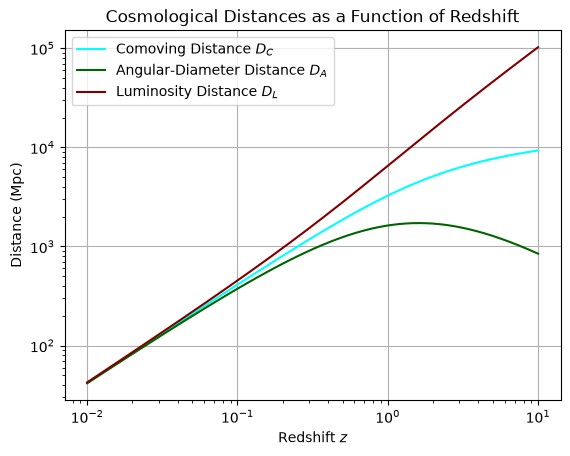

In [9]:
# We want lots of points close to z=0 (where things change fast) and
# fewer points out at high z (where things change more slowly), so we
# build the array in three chunks and glue them together

z_values_1 = np.linspace(0.01, 0.1, 200)
z_values_2 = np.linspace(0.1, 1, 200)
z_values_3 = np.linspace(1, 10, 200)
z_values = np.concatenate((z_values_1, z_values_2, z_values_3))
 
# Calculating the integral to find D_c values::
D_c_values = np.array([comoving_distance(z) for z in z_values])
 
# Once we already have D_c_values for every redshift, we write:
# D_A=1/(1+z)*integral(c/H(z)) not integral(c/{H(z)*(1+z)})
D_A_values = D_c_values / (1 + z_values)  
D_L_values = D_c_values * (1 + z_values)
 
# Plotting
plt.plot(z_values, D_c_values, label='Comoving Distance $D_C$', color='cyan') #plt.figure(figsize=(6, 3))
plt.plot(z_values, D_A_values, label='Angular-Diameter Distance $D_A$', color="darkgreen")
plt.plot(z_values, D_L_values, label='Luminosity Distance $D_L$', color='maroon')

plt.xscale('log')  
plt.yscale('log') 
 
plt.xlabel('Redshift $z$') 
plt.ylabel('Distance (Mpc)')
plt.title('Cosmological Distances as a Function of Redshift')
plt.legend()
plt.grid(True)
plt.savefig('Saved Data/cosmological_distances.png', dpi=150, bbox_inches='tight')
plt.show()

We will plot the theoritical distance modulus for the parameters, that we set in the starting.

And see how our parametric model agrees with the observed pantheon data.


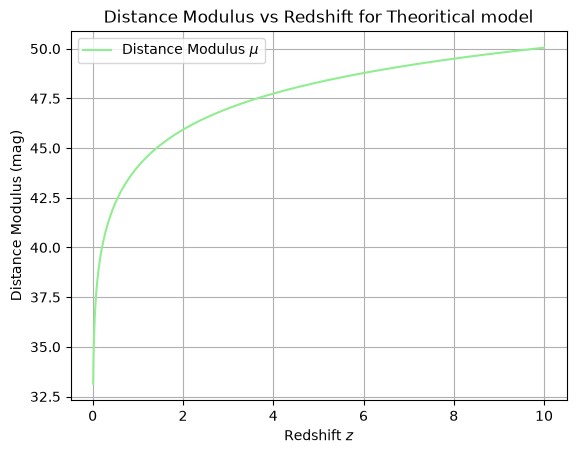

In [10]:

mu_values = 5 * np.log10(D_L_values) + 25

plt.plot(z_values, mu_values, label='Distance Modulus $\\mu$', color='lightgreen')

plt.xlabel('Redshift $z$')
plt.ylabel('Distance Modulus (mag)')
plt.title('Distance Modulus vs Redshift for Theoritical model')
plt.legend()
plt.grid(True)
plt.savefig('Saved Data/distance_modulus_theory.png', dpi=150, bbox_inches='tight')
plt.show()

# on logarithmic scale, plot will be straight line with slope 5

Read the Pantheon data 

In [11]:
data = pd.read_csv("Pantheon Data/Pantheon_SNdata.csv")

print(data.head)

<bound method NDFrame.head of        #name     zcmb     zhel  dz        mb      dmb  dist_mod
0     2002cr  0.01012  0.01012   0  13.90745  0.19825  33.25745
1     2002dp  0.01038  0.01038   0  14.04960  0.20480  33.39960
2     2009an  0.01043  0.01043   0  13.92480  0.20035  33.27480
3     2006bh  0.01082  0.01082   0  14.00860  0.18445  33.35860
4     1998dk  0.01209  0.01209   0  13.97910  0.19140  33.32910
...      ...      ...      ...  ..       ...      ...       ...
1043   Primo  1.55000  1.55000   0  26.00705  0.18565  45.35705
1044    geta  1.70000  1.70000   0  26.05920  0.28320  45.40920
1045   stone  1.80000  1.80000   0  26.20110  0.18795  45.55110
1046  wilson  1.91400  1.91400   0  26.16090  0.25590  45.51090
1047  colfax  2.26000  2.26000   0  26.87700  0.25480  46.22700

[1048 rows x 7 columns]>


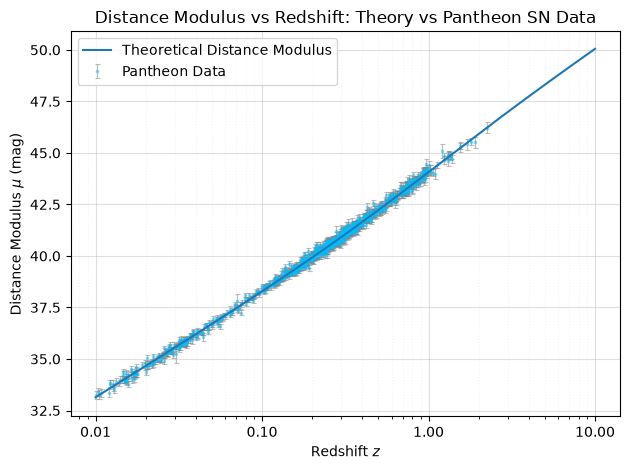

In [12]:
plt.plot(z_values, mu_values, label='Theoretical Distance Modulus', zorder=2)
 
plt.errorbar(
    data['zcmb'], data['dist_mod'], yerr=data['dmb'],
    fmt='o', mfc='deepskyblue', mec='none', ms=2.5,
    ecolor='gray', alpha=0.5,
    capsize=1.8, capthick=0.8, elinewidth=0.9,
    label='Pantheon Data', zorder=1
)
 
plt.xscale('log')
ax = plt.gca()
ax.set_xticks([0.01, 0.1, 1, 10])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
 
plt.xlabel('Redshift $z$')
plt.ylabel(r'Distance Modulus $\mu$ (mag)')
plt.title('Distance Modulus vs Redshift: Theory vs Pantheon SN Data')
plt.legend()
plt.grid(True, which='both', alpha=0.3)

ax.grid(True, which='major', alpha=0.4)
ax.grid(True, which='minor', alpha=0.15, linestyle=':')
 
plt.tight_layout()
plt.savefig('Saved Data/distance_modulus_vs_pantheon.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Conclusion

All three distances come from the same comoving integral

$$D_C = \int_0^z \frac{c\,\mathrm{d}z'}{H(z')}, \qquad D_A = \frac{D_C}{1+z}, \qquad D_L = (1+z)D_C$$

so they differ only by factors of $(1+z)$, giving $D_L = (1+z)^2 D_A$. At low $z$ they
converge, which is why the distinction can be ignored for the nearby cluster in
`Cepheid Variables/` but not here. $D_A$ turns over near $z \approx 1.6$: beyond that an
object looks *larger* the further away it is.

Supernovae need $D_L$, since it is defined by how flux falls off, giving

$$\mu = 5\log_{10}\left(\frac{D_L}{\text{Mpc}}\right) + 25$$

**The theory curve tracks Pantheon across $0.01 < z < 2$** for a fiducial $H_0$ and
$\Omega_m$ set by hand. So the model has the right shape and the remaining job is
parameter estimation, not model selection. But the fit is not exact and the residual is
not obviously random, so the parameters need a likelihood and a sampler rather than eye.

Individual supernovae carry $\sim 0.2$ mag errors, so none constrains anything alone.
The constraint comes from averaging ~1000 of them over a wide redshift baseline, which
is the lever arm the single-cluster Cepheid measurement lacked.